# Número efectivo de rectas para separar 5 puntos en $\mathbb{R}^2$

En el plano hay infinitas rectas, así que contarlas directamente no tiene sentido. Lo que sí se puede contar es cuántas cosas *distintas* logran hacer esas rectas sobre un conjunto fijo de puntos. Dos rectas que clasifican los 5 puntos exactamente igual son indistinguibles desde el punto de vista del aprendizaje, así que cuentan como una sola.

El número efectivo de rectas es entonces la cantidad de etiquetados distintos (dicotomías) que un perceptrón puede producir sobre los 5 puntos. Esa cantidad es la función de crecimiento $m_{\mathcal{H}}(N)$ evaluada en $N=5$.

Con 5 puntos y 2 etiquetas hay $2^5 = 32$ etiquetados posibles en total. La pregunta es cuántos de esos 32 se pueden lograr con una recta, y cuántos son imposibles.

## Criterio de separabilidad

Un etiquetado es separable por una recta si existe algún $(w, b)$ tal que

$$y_i\,(w\cdot x_i + b) \ge 1 \qquad \text{para todo } i=1,\dots,5.$$

Esas son restricciones lineales en $(w,b)$, así que decidir si el etiquetado es separable es un problema de factibilidad lineal: se le pide a un solver que encuentre cualquier punto que las cumpla, y si el sistema es infactible entonces ninguna recta separa ese etiquetado.

(Geométricamente el criterio equivalente es que los cascos convexos de las dos clases no se corten.)

In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from math import comb

def es_separable(X, y):
    # ¿existe (w,b) con y_i (w·x_i + b) >= 1?  -> factibilidad de un LP
    m = len(y)
    A = -(y[:, None] * np.hstack([X, np.ones((m, 1))]))   # -y_i[x_i,1]·[w,b] <= -1
    r = linprog(np.zeros(3), A_ub=A, b_ub=-np.ones(m),
                bounds=[(None, None)] * 3, method="highs")
    return r.status == 0

def clasificar_etiquetados(X):
    separables, imposibles = [], []
    for bits in itertools.product([-1, 1], repeat=len(X)):
        y = np.array(bits)
        (separables if es_separable(X, y) else imposibles).append(bits)
    return separables, imposibles

## Enumeración de los 32 etiquetados

Se usan 5 puntos en posición convexa (los vértices de un pentágono). Más adelante se comprueba que la respuesta no depende de esta elección.

In [2]:
ang = np.linspace(0, 2*np.pi, 6)[:-1] + 0.3
P = np.c_[np.cos(ang), np.sin(ang)]      # 5 vértices de un pentágono

sep, imp = clasificar_etiquetados(P)
print("etiquetados posibles en total : 2^5 =", 2**5)
print("separables por una recta      :", len(sep))
print("imposibles para una recta     :", len(imp))

etiquetados posibles en total : 2^5 = 32
separables por una recta      : 22
imposibles para una recta     : 10


De los $32$ etiquetados, solo $22$ se consiguen con una recta y $10$ son imposibles. Ese $22$ es el número efectivo de rectas: $m_{\mathcal{H}}(5) = 22$.

## Los 32 casos, uno por uno

Cada panel muestra un etiquetado (círculos azules para $+1$, cuadrados rojos para $-1$). Cuando existe recta separadora se dibuja; los paneles marcados en rojo son los etiquetados que ninguna recta puede lograr.

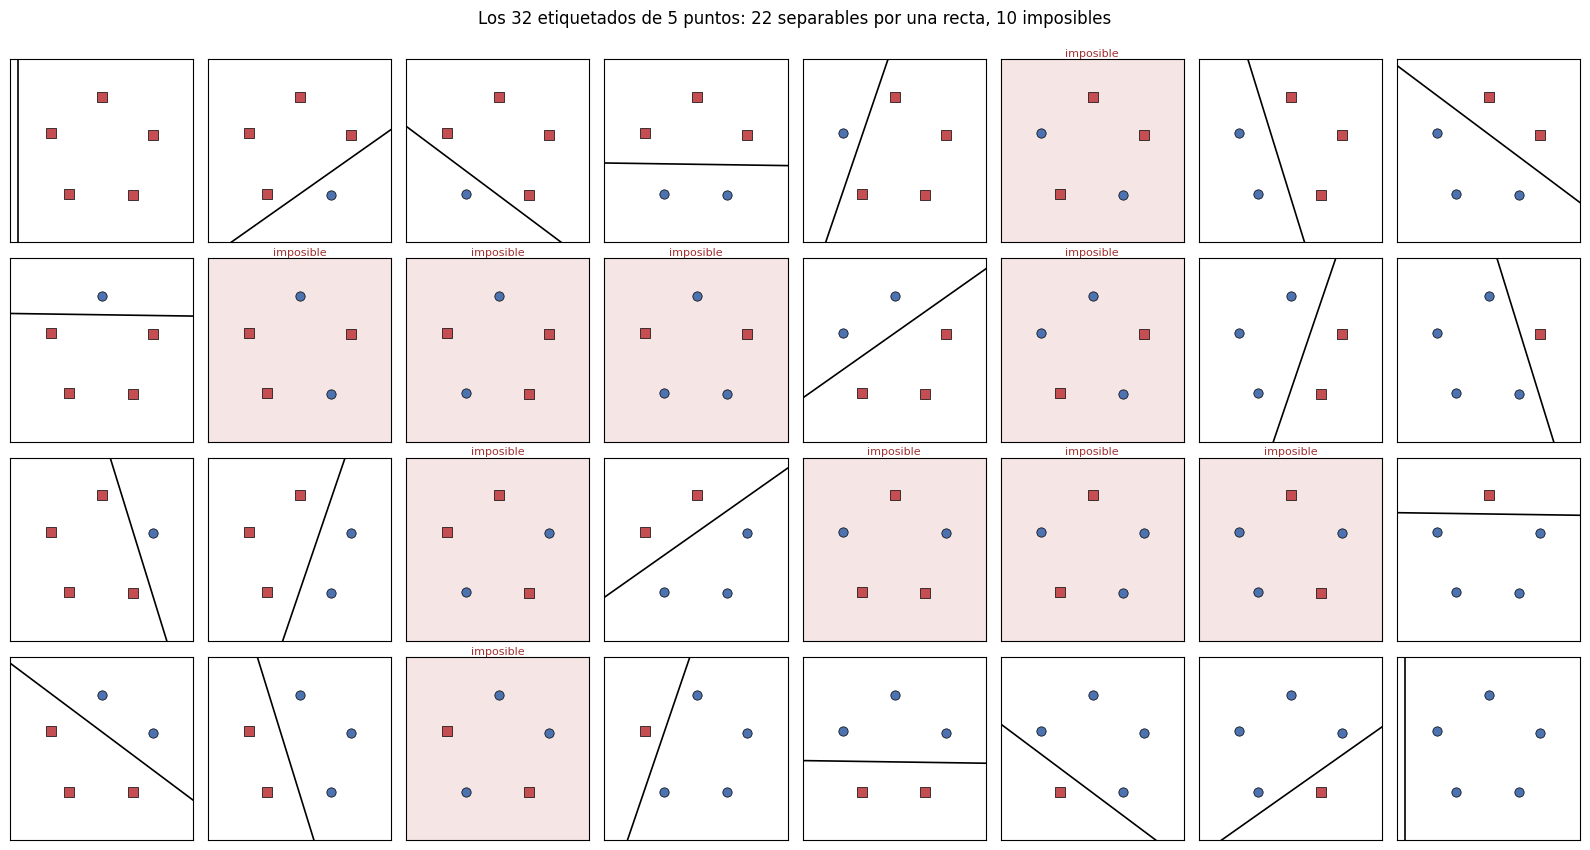

In [3]:
from sklearn.svm import SVC

def recta_separadora(X, y):
    # None si no hay recta; "trivial" si todos son de una clase; si no, (b, w1, w2)
    if not es_separable(X, y):
        return None
    if len(np.unique(y)) == 1:              # una sola clase: cualquier recta al margen sirve
        return "trivial"
    clf = SVC(kernel="linear", C=1e6).fit(X, y)   # se toma la de máximo margen (más legible)
    return np.r_[clf.intercept_[0], clf.coef_[0]]

fig, axes = plt.subplots(4, 8, figsize=(16, 8.5))
for ax, bits in zip(axes.ravel(), itertools.product([-1, 1], repeat=5)):
    y = np.array(bits)
    w = recta_separadora(P, y)

    ax.scatter(P[y == 1, 0], P[y == 1, 1], c="#4C72B0", s=45,
               edgecolors="k", linewidths=0.5, zorder=3)
    ax.scatter(P[y == -1, 0], P[y == -1, 1], c="#C44E52", s=45, marker="s",
               edgecolors="k", linewidths=0.5, zorder=3)

    if w is None:                                   # no separable
        ax.set_facecolor("#f6e5e5")
        ax.set_title("imposible", fontsize=8, color="#a03030", pad=2)
    elif isinstance(w, str):                        # todos de un mismo lado
        ax.axvline(-1.55, color="k", lw=1.2)
    else:
        xs = np.array([-1.7, 1.7])
        if abs(w[2]) > 1e-9:
            ax.plot(xs, -(w[0] + w[1]*xs) / w[2], "k-", lw=1.2)
        else:
            ax.axvline(-w[0]/w[1], color="k", lw=1.2)

    ax.set_xlim(-1.7, 1.7); ax.set_ylim(-1.7, 1.7)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")

plt.suptitle("Los 32 etiquetados de 5 puntos: 22 separables por una recta, 10 imposibles", y=0.995)
plt.tight_layout(); plt.show()

## Conclusión

El número efectivo de rectas para separar $5$ puntos en $\mathbb{R}^2$ en dos etiquetas es

$$m_{\mathcal{H}}(5) = 22 .$$

De los $32$ etiquetados posibles, $22$ se logran con alguna recta y $10$ son imposibles. Los imposibles son los patrones alternados (una clase partida en pedazos separados por la otra), del mismo tipo que el XOR; con los puntos en posición convexa son las $5$ parejas de vértices no vecinos y sus complementos.

Lo importante del resultado es que $22$ es mucho menor que $32$: aunque el conjunto hipótesis del perceptrón es infinito, sobre $5$ puntos se comporta como si tuviera solo $22$ hipótesis. Eso es lo que permite reemplazar el $M$ infinito de la cota de Hoeffding por una cantidad finita y obtener garantías de aprendizaje.